<a href="https://colab.research.google.com/github/MerakiElysian/RAG/blob/main/RAG_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
#import libraries
!pip install sentence-transformers faiss-cpu langchain
!pip install pypdf langchain_community
!pip install langchain-text-splitters

In [44]:
#upload the document
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
  print("Uploded:", filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report (2).pdf
Uploded: Microsoft 2025 Annual Report (2).pdf


In [45]:
from langchain_community.document_loaders import PyPDFLoader
pdf_file = list(uploaded.keys())[0]
loader = PyPDFLoader(pdf_file)
pages = loader.load_and_split()
print("Number of pages loaded", len(pages))

Number of pages loaded 89


In [46]:
print(pages[0])

page_content='HomeShareholder LetterFinancial Review
Directors & OfficersInvestor Relations
Business
Discussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotes
Auditor's ReportControls & Procedures
GeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable Information
Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 1/63' metadata={'producer': 'Skia/PDF m145', 'creator': 'Mozil

In [47]:
#Chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 100)
chunks = text_splitter.split_documents(pages)
print("Total chunks created: ",len(chunks))

Total chunks created:  709


In [48]:
print(chunks[1].page_content)

Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report


In [49]:
#embeddings from the chunks
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
#22 million parameter model

embeddings = model.encode([chunk.page_content for chunk in chunks])
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Dimension of the embeddings: ", dimension)
print("Total number of index", index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimension of the embeddings:  384
Total number of index 709


In [50]:
import matplotlib.pyplot as plt

def visualize_embeddings(vector, chunk_text = None, max_text_chars = 500):
  vector = np.array(vector)
  normalized  = (vector - vector.min())/(vector.max()- vector.min())
  color_band = normalized.reshape(1,-1)

  if chunk_text is not None:
    print("Chunk text \n")
    print(chunk_text[:max_text_chars])
    print()
  plt.figure(figsize=(12,2))
  plt.imshow(color_band, aspect = "auto", cmap = "viridis")
  plt.yticks([])
  plt.xlabel(f"Embedding Dimensions ({len(vector)})")
  plt.title("vector representation")
  plt.show()

Chunk text 

Accounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo Data
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report



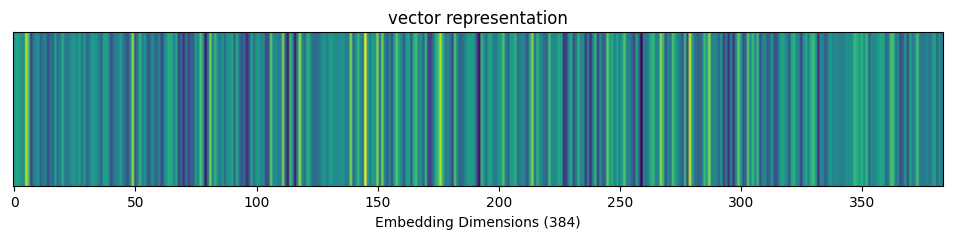

In [51]:
visualize_embeddings(embeddings[1], chunks[1].page_content)

Enter your Question: How much profit did microsoft make in 2025 compared to 2024?
Chunk text 

How much profit did microsoft make in 2025 compared to 2024?



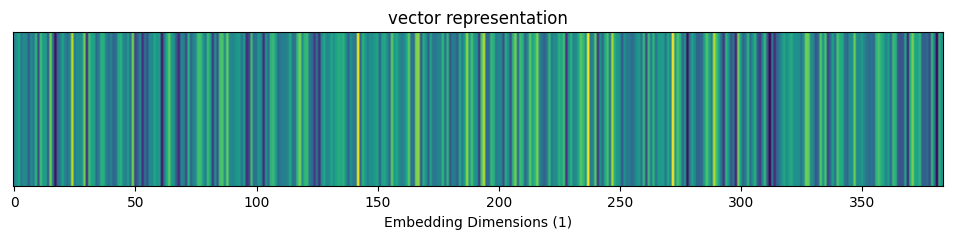

In [52]:
# Retrieval

query = input("Enter your Question: ")
query_embedding = model.encode([query])
visualize_embeddings(query_embedding, query)

In [53]:
D, I = index.search(np.array(query_embedding), k = 5)
retrieved_chunks = [chunks[i] for i in I[0]]

print("Top chunks retrieved: ")

for chunk in retrieved_chunks:
  print(chunk.page_content)
  print("Page:", chunk.metadata["page"])
  print("------------------")

Top chunks retrieved: 
Cost of revenue 40,171 29,611 24,109
Operating expenses 21,505 20,040 20,424
Operating Income 44,589 37,813 28,411
More Personal Computing
Revenue 54,649 50,838 44,820
Cost of revenue 25,238 24,892 24,552
Operating expenses 15,245 13,987 10,230
Operating Income 14,166 11,959 10,038
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 56/63
Page: 55
------------------
Revenue 120,810 106,820 13%
Cost of revenue 22,422 19,611 14%
Operating expenses 28,615 27,548 4%
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 19/63
Page: 18
------------------
Highlights from fiscal year 2025 compared with fiscal year 2024 included:
Microsoft Cloud revenue increased 23% to $168.9 billion.
Microsoft 365 Commercial products and cloud services revenue increased 14% driven by Microsoft 365 Commercialcloud revenue grow

In [54]:
# ReRanking

from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

pairs = [(query, chunk.page_content)  for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores, retrieved_chunks), key = lambda x:x[0], reverse = True )

print("After reranking: \n")

for score, chunk in ranked_chunks:
  print("score", score)
  print(chunk.page_content)
  print("Page number: ", chunk.metadata["page"])
  print("------=-==-==-=--------")

  # before reranking order = 55 18 15 6 41
  # after reranking order = 15 18 55 6 41

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


After reranking: 

score 7.9931393
Highlights from fiscal year 2025 compared with fiscal year 2024 included:
Microsoft Cloud revenue increased 23% to $168.9 billion.
Microsoft 365 Commercial products and cloud services revenue increased 14% driven by Microsoft 365 Commercialcloud revenue growth of 15%.
Microsoft 365 Consumer products and cloud services revenue increased 11% driven by Microsoft 365 Consumer cloudrevenue growth of 11%.
LinkedIn revenue increased 9%.
Page number:  15
------=-==-==-=--------
score 4.175114
Revenue 120,810 106,820 13%
Cost of revenue 22,422 19,611 14%
Operating expenses 28,615 27,548 4%
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 19/63
Page number:  18
------=-==-==-=--------
score 2.312167
Cost of revenue 40,171 29,611 24,109
Operating expenses 21,505 20,040 20,424
Operating Income 44,589 37,813 28,411
More Personal Computing
Revenue 54,649 50,838 44,820
Cost of reve

In [55]:
# combine reranked chunk with context

top_chunks = [chunk.page_content for _, chunk in ranked_chunks[:3]]
context = "\n\n".join(top_chunks)
print(context)

Highlights from fiscal year 2025 compared with fiscal year 2024 included:
Microsoft Cloud revenue increased 23% to $168.9 billion.
Microsoft 365 Commercial products and cloud services revenue increased 14% driven by Microsoft 365 Commercialcloud revenue growth of 15%.
Microsoft 365 Consumer products and cloud services revenue increased 11% driven by Microsoft 365 Consumer cloudrevenue growth of 11%.
LinkedIn revenue increased 9%.

Revenue 120,810 106,820 13%
Cost of revenue 22,422 19,611 14%
Operating expenses 28,615 27,548 4%
Annual Report 2025
general  
14/03/2026, 23:44 Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 19/63

Cost of revenue 40,171 29,611 24,109
Operating expenses 21,505 20,040 20,424
Operating Income 44,589 37,813 28,411
More Personal Computing
Revenue 54,649 50,838 44,820
Cost of revenue 25,238 24,892 24,552
Operating expenses 15,245 13,987 10,230
Operating Income 14,166 11,959 10,038
Annual Report 2025
general  
14/03/2026, 2

In [56]:
!pip install -U google-genai

In [59]:
from google import genai

from google.colab import userdata

# Set your API key
API_KEY = userdata.get('gemini-api')

# Create client
client = genai.Client(api_key=API_KEY)

# Prompt
prompt = f"""
Given the following context, please answer the question.

Context:
{context}

Question:
{query}

Answer:
Provide a concise answer. If the information is not in the context, say:
'The information is not found in the document.'
"""

# Generate response
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents = prompt
)

print("Generated Answer:")
print(response.text)

Generated Answer:
Microsoft's operating income in 2025 was $44,589 million, compared to $37,813 million in 2024. This represents an increase of $6,776 million.


Enter your Question: How much percentage increase sales of microsoft from 2024 to 2025?
Chunk text 

How much percentage increase sales of microsoft from 2024 to 2025?



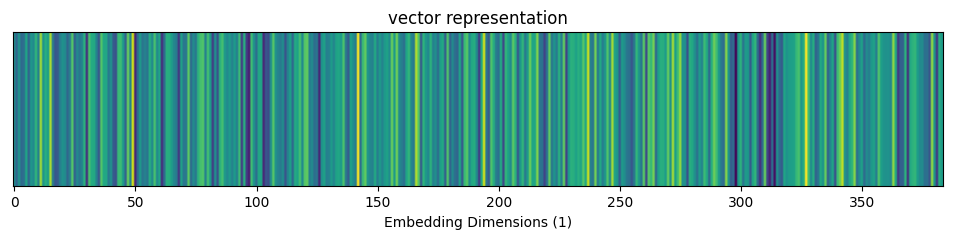

Generated Answer:
13%


In [60]:
query = input("Enter your Question: ")
query_embedding = model.encode([query])
visualize_embeddings(query_embedding, query)

D, I = index.search(np.array(query_embedding), k = 5)
retrieved_chunks = [chunks[i] for i in I[0]]

pairs = [(query, chunk.page_content)  for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores, retrieved_chunks), key = lambda x:x[0], reverse = True )

top_chunks = [chunk.page_content for _, chunk in ranked_chunks[:3]]
context = "\n\n".join(top_chunks)

# Prompt
prompt = f"""
Given the following context, please answer the question.

Context:
{context}

Question:
{query}

Answer:
Provide a concise answer. If the information is not in the context, say:
'The information is not found in the document.'
"""

# Generate response
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents = prompt
)

print("Generated Answer:")
print(response.text)

In [62]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
